# Overview: MI cascade analysis in the HGSOC dataset

This notebook analyzes **meta-interaction (MI) cascades** in the **HGSOC spatial transcriptomics dataset** using **SpiderNet-inferred MI programs**.  
Its main goal is to identify how different **MI programs are spatially linked**, which **cell-type triplets** are involved, and how these cascade patterns relate to downstream **signaling activity** and **malignant-cell gene programs**.

The notebook mainly performs the following analyses:

1. **Load processed HGSOC data and inferred MI representations**  
   Read the processed data, **cell-level MI factors**, spatial information, and metadata needed for cascade analysis.

2. **Identify significant MI cascade pairs**  
   Quantify **MI–MI spatial colocalization** and detect significant **upstream–downstream MI pairs** as candidate cascade structures.

3. **Summarize cascade organization and associated cell-type triples**  
   Visualize the global MI cascade structure and identify enriched **cell-type triplets** involved in each cascade.

4. **Inspect selected cascades and their signaling features**  
   Examine selected cascades in tissue space and compare cascade-related groups by **ligand–receptor activity**, **gene-expression patterns**, and other signaling features.

5. **Characterize downstream transcriptional programs**  
   Perform **differential expression** and **GO enrichment** analyses to interpret the downstream malignant-cell programs associated with selected MI cascades.

Overall, this notebook provides a framework for linking **higher-order intercellular communication structure** to **cell-type organization**, **spatial signaling patterns**, and **downstream malignant-cell states** in HGSOC.

## 1. Imports and device setup

In [1]:
import json

import numpy as np

from SpiderNet.utils import *
from SpiderNet.config import *
from dataclasses import fields
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

cuda_available = torch.cuda.is_available()
if cuda_available:
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Configure paths

In [2]:
from pathlib import Path

PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/HGSOC/ProcessedData")
OUTPUT_ROOT = Path("D:/SpiderNet/Results/HGSOC")
DATA_ROOT = Path("D:/SpiderNet/Data/HGSOC")

setup_path = OUTPUT_ROOT / "HGSOC_modeltraining_setup.json"
if setup_path.exists():
    with open(setup_path, "r", encoding="utf-8") as handle:
        training_setup = json.load(handle)
    PROCESSED_DATA_DIR = Path(training_setup.get("PROCESSED_DATA_DIR", PROCESSED_DATA_DIR))
    OUTPUT_ROOT = Path(training_setup.get("OUTPUT_ROOT", OUTPUT_ROOT))

print(f"Processed data: {PROCESSED_DATA_DIR}")
print(f"Training results: {OUTPUT_ROOT}")
print(f"Auxiliary data: {DATA_ROOT}")

Processed data: D:\SpiderNet\Results\HGSOC\ProcessedData
Training results: D:\SpiderNet\Results\HGSOC
Auxiliary data: D:\SpiderNet\Data\HGSOC


## 3. Load training results

In [3]:
import re

run_dirs_path = OUTPUT_ROOT / "run_dirs.json"
if not run_dirs_path.exists():
    raise FileNotFoundError(f"Cannot find run_dirs.json: {run_dirs_path}")

with open(run_dirs_path, "r", encoding="utf-8") as handle:
    run_dirs = json.load(handle)

run_dir = Path(run_dirs["run_dir"])
match = re.search(r"Result_dim(\d+)", str(run_dir))
if match is None:
    raise ValueError(f"Cannot parse dim_envir from run directory: {run_dir}")
dim_envir = int(match.group(1))

print(run_dirs)
print(f"dim_envir = {dim_envir}")

{'run_dir': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15', 'model_dir': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Model'}
dim_envir = 15


## 4. Load processed HGSOC data

In [4]:
from SpiderNet.io import load_processed_data
processed = load_processed_data(PROCESSED_DATA_DIR)

SpiderNet_data_pyg_list = processed.spidernet_data
adata_list = processed.adata_list
samples_name_list = [np.unique(adata_list[i].obs["samples"])[0] for i in range(len(adata_list))]

## 5. load the inferred MI

In [5]:
Factor_envir_list = pd.read_pickle(run_dirs["run_dir"] + f"/Factor_envir_list.pkl")

## 6. Identify the significant MI cascade structures

In [6]:
# Thresholds for MI cascade analysis
MI_threshold = 0.6

In [7]:
zscore_countcolocal_threshold = 1.4
pvalue_adjusted_threshold = 0.001

In [8]:
from SpiderNet.analysis import MI_colocalization_analysis
result = MI_colocalization_analysis(
    Factor_envir_list=Factor_envir_list,
    SpiderNet_data_pyg_list=SpiderNet_data_pyg_list,
    adata_list=adata_list,
    MI_threshold=MI_threshold,
    nperm=100,
    fdr_alpha=0.05,
    celltype_col="cell.types",
    progress_every=5,
    zscore_countcolocal_threshold = zscore_countcolocal_threshold,
    pvalue_adjusted_threshold = pvalue_adjusted_threshold
)
colocal_count_merge_sum_zscore = result["colocal_count_merge_sum_zscore"]
colocal_count_merge_sum_pvalue = result["colocal_count_merge_sum_pvalue_fdr"]

Processing sample 1/48 (0.00%)
Processing sample 6/48 (10.42%)
Processing sample 11/48 (20.83%)
Processing sample 16/48 (31.25%)
Processing sample 21/48 (41.67%)
Processing sample 26/48 (52.08%)
Processing sample 31/48 (62.50%)
Processing sample 36/48 (72.92%)
Processing sample 41/48 (83.33%)
Processing sample 46/48 (93.75%)
Significant MI-MI co-localizations: 21


In [9]:
MI_colocal_summary = pd.DataFrame({
    "zscore_countcolocal": np.array(colocal_count_merge_sum_zscore).flatten(),
    "pvalue_adjusted": np.array(colocal_count_merge_sum_pvalue).flatten(),
    "MI_first": np.repeat(np.arange(1, dim_envir + 1), dim_envir),
    "MI_second": np.tile(np.arange(1, dim_envir + 1), dim_envir)
})
MI_colocal_summary_significant = MI_colocal_summary.loc[(MI_colocal_summary['zscore_countcolocal'] > np.log2(zscore_countcolocal_threshold)) & (MI_colocal_summary['pvalue_adjusted'] < 0.001),:]

In [10]:
np.power(2,0.481)

1.3957107641221664

## 7. Hierarchical clustering heatmap of MI-MI colocalization Z-scores

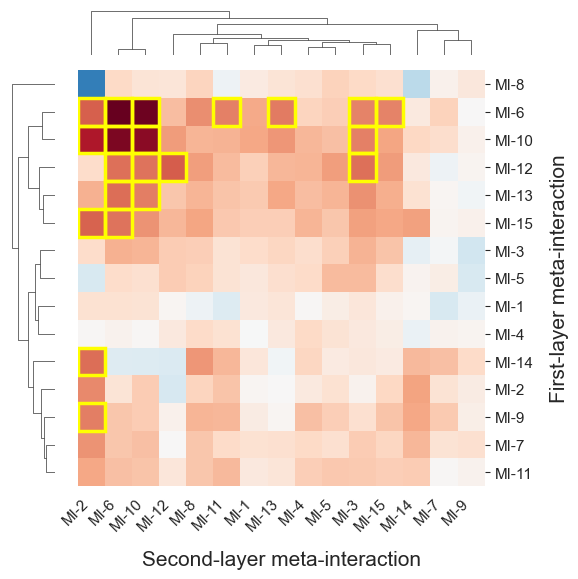

✅ Heatmap saved to: D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15/Heatmap_Zscore_Colocalization_Count_allsample.png


In [11]:
# =========================================
# Hierarchical clustering heatmap
# =========================================
g = sns.clustermap(
    colocal_count_merge_sum_zscore,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,                   # enhance contrast range
    figsize=(7, 6),
    square=False,                      # True makes text cramped
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=None,                     # hide color bar for cleaner layout
)

# =========================================
# Retrieve clustered row/column order
# =========================================
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

# =========================================
# Highlight significant MI-MI pairs 
# (p < 1e-3 and Zscore > log2(zscore_countcolocal_threshold))
# =========================================
for i_new, i_old in enumerate(row_order):
    for j_new, j_old in enumerate(col_order):
        p_val = colocal_count_merge_sum_pvalue.iloc[i_old, j_old]
        z_val = colocal_count_merge_sum_zscore.iloc[i_old, j_old]
        if p_val < 1e-3 and z_val > np.log2(zscore_countcolocal_threshold):
            g.ax_heatmap.add_patch(
                Rectangle(
                    (j_new, i_new),
                    1, 1,
                    fill=False,
                    edgecolor="yellow",
                    lw=2.5
                )
            )

# =========================================
# Axis labels and tick style
# =========================================
g.ax_heatmap.set_xlabel("Second-layer meta-interaction", fontsize=15, labelpad=12)
g.ax_heatmap.set_ylabel("First-layer meta-interaction", fontsize=15, labelpad=12)

# Adjust tick labels orientation and font
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45, ha="right", fontsize=11
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0, fontsize=11
)

# =========================================
# Layout and save
# =========================================
g.fig.tight_layout()
g.fig.subplots_adjust(bottom=0.18, left=0.18)   # add margins to avoid label clipping

out_path = run_dirs["run_dir"] + "/Heatmap_Zscore_Colocalization_Count_allsample.png"
g.fig.savefig(out_path, dpi=300)
out_path_pdf = run_dirs["run_dir"] + "/Heatmap_Zscore_Colocalization_Count_allsample.pdf"
g.fig.savefig(out_path_pdf, dpi=300)
plt.show()
plt.close()

print(f"✅ Heatmap saved to: {out_path}")


## 8. Enriched Celltype Triple Summary and Visualization

In [12]:
from SpiderNet.analysis import summarize_mi_cascade_celltype_triples
cascade_res = summarize_mi_cascade_celltype_triples(
    MI_colocal_summary_significant=MI_colocal_summary_significant,
    Factor_envir_norm_list=Factor_envir_list,
    hyper_edge_adj_list=result["hyper_edge_adj_list"],
    SpiderNet_data_pyg_list=SpiderNet_data_pyg_list,
    adata_list=adata_list,
    MI_threshold=MI_threshold,
    celltype_col="cell.types",
    sample_col="samples",
    select_triple_prop_threshold=0.1,
    progress_every=10,
)
prop_avg_allsample_filter_merge_pivot_select = cascade_res["prop_avg_allsample_filter_merge_pivot_select"]

Processing MI pair 1/21
Processing MI pair 11/21
Processing MI pair 21/21
Summary completed.
Selected pivot shape: (10, 21)


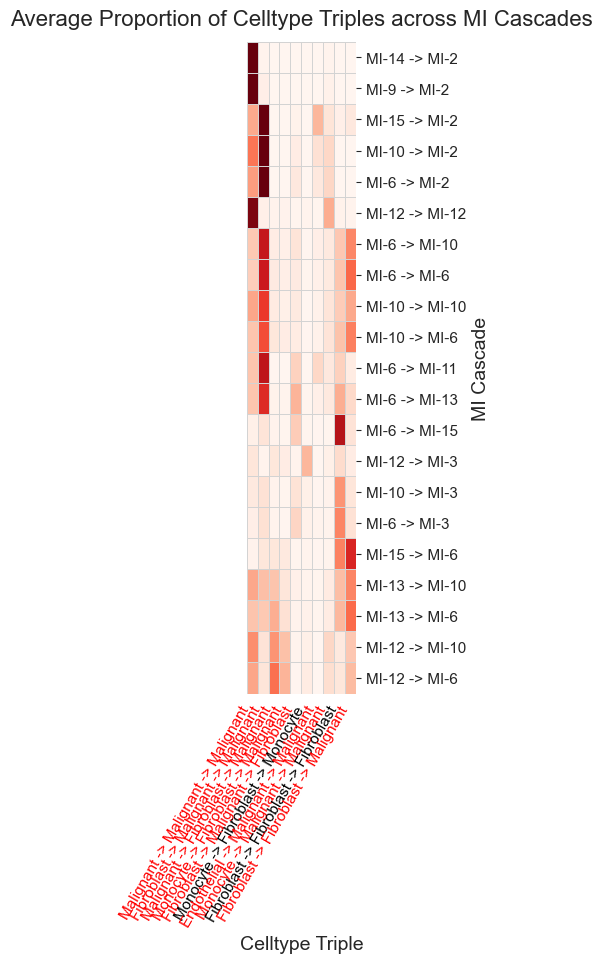

Saved: Heatmap_Average_prop_Celltype_triple_across_MI_cascades.pdf


In [13]:
from SpiderNet.visualization import Heatmap_celltypetriplet_prop
# ==============================================================
# 1. Heatmap for all celltype triples across all MI cascades
# ==============================================================
Heatmap_celltypetriplet_prop(
    prop_avg_allsample_filter_merge_pivot_select,
    title="Average Proportion of Celltype Triples across MI Cascades",
    xlabel="Celltype Triple",
    ylabel="MI Cascade",
    filename="Heatmap_Average_prop_Celltype_triple_across_MI_cascades.pdf",
    highlight_malignant=True,
    file_savepath_main=run_dirs["run_dir"]
)

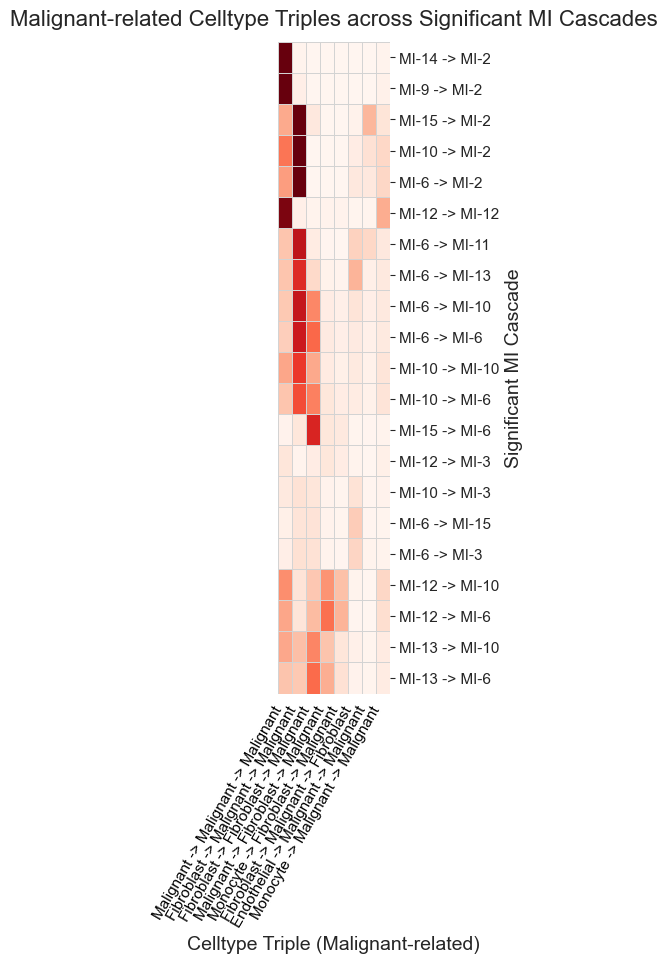

Saved: Heatmap_Average_prop_Celltype_triple_across_MI_cascades_Malignant.pdf


In [14]:
# ==============================================================
# 2. Heatmap for Malignant-related celltype triples only
# ==============================================================
prop_malignant = prop_avg_allsample_filter_merge_pivot_select.loc[
    prop_avg_allsample_filter_merge_pivot_select.index.str.contains("Malignant")
]

Heatmap_celltypetriplet_prop(
    prop_malignant,
    title="Malignant-related Celltype Triples across Significant MI Cascades",
    xlabel="Celltype Triple (Malignant-related)",
    ylabel="Significant MI Cascade",
    filename="Heatmap_Average_prop_Celltype_triple_across_MI_cascades_Malignant.pdf",
    file_savepath_main = run_dirs["run_dir"]
)

## 9.In-situ Visualization of MI Cascades of interest (cell1-[MI-i]>cell2-[MI-j]>cell3)

In [15]:
print(MI_colocal_summary_significant)

     zscore_countcolocal  pvalue_adjusted  MI_first  MI_second
76              0.598467         0.000012         6          2
77              0.494188         0.000012         6          3
80              1.072941         0.000012         6          6
84              0.977393         0.000012         6         10
85              0.505056         0.000012         6         11
87              0.519097         0.000012         6         13
89              0.498046         0.000012         6         15
121             0.508181         0.000012         9          2
136             0.811046         0.000012        10          2
137             0.505835         0.000012        10          3
140             0.945016         0.000012        10          6
144             0.901965         0.000012        10         10
167             0.553427         0.000012        12          3
170             0.553097         0.000012        12          6
174             0.540010         0.000012        12    

### Specify the upstream and downstream MI of interest, and cell type triple

In [16]:
MI_first_of_interest = 12
MI_second_of_interest = 10
celltype_triple_of_interest = 'Monocyte -> Fibroblast -> Malignant'

In [17]:
search_index = np.where(
    (MI_colocal_summary_significant['MI_first'] == MI_first_of_interest) &
    (MI_colocal_summary_significant['MI_second'] == MI_second_of_interest)
)[0][0]
MI_first_index = int(MI_first_of_interest) - 1
MI_second_index = int(MI_second_of_interest) - 1
ct1_cur = celltype_triple_of_interest.split("->")[0].strip()
ct2_cur = celltype_triple_of_interest.split("->")[1].strip()
ct3_cur = celltype_triple_of_interest.split("->")[2].strip()
cell_types_triplet = (ct1_cur, ct2_cur, ct3_cur)
celltriple_index_sample_cur = cascade_res["celltriple_index_sample_list"][search_index]

print(f"Now showing: {ct1_cur} -> {ct2_cur} -> {ct3_cur}, MI-{MI_first_of_interest} -> MI-{MI_second_of_interest}")


Now showing: Monocyte -> Fibroblast -> Malignant, MI-12 -> MI-10


### Visualize the MI cascade in-situ for each sample

In [18]:
from SpiderNet.visualization import insituplot_MIcascade
# ---------- Define color map ----------
classes = np.unique(adata_list[0].obs["cell.types"])
color_map = dict(zip(
    classes,
    ["#1f77b4", "#17becf", "#c49c94", "#b22222",
     "#9467bd", "#ff7f0e", "#2ca02c"]
))

# ==============================================================
# Loop over samples
# ==============================================================
for sample_index in range(len(adata_list)):
    adata_cur = adata_list[sample_index]
    spatial = adata_cur.obsm["spatial"]
    celltypes = adata_cur.obs["cell.types"].values

    triple_edges = celltriple_index_sample_cur[sample_index]

    if triple_edges is None or len(triple_edges) == 0:
        continue

    # Select the target cell-type triple: ct1 -> ct2 -> ct3
    triple_ct = celltypes[triple_edges]
    mask = (
        (triple_ct[:, 0] == ct1_cur) &
        (triple_ct[:, 1] == ct2_cur) &
        (triple_ct[:, 2] == ct3_cur)
    )
    triple_edges = triple_edges[mask]

    if triple_edges.shape[0] == 0:
        continue

    # Split one triple into two directed edges:
    # edge_first:  cell1 -> cell2
    # edge_second: cell2 -> cell3
    edge_first = triple_edges[:, [0, 1]]
    edge_second = triple_edges[:, [1, 2]]

    # Plot and save
    insituplot_MIcascade(
        spatial=spatial,
        celltypes=celltypes,
        edge_first=edge_first,
        edge_second=edge_second,
        color_map=color_map,
        sample_index=sample_index,
        ct1=ct1_cur,
        ct2=ct2_cur,
        ct3=ct3_cur,
        MI_first_id=MI_first_of_interest,
        MI_second_id=MI_second_of_interest,
        save_dir=run_dirs["run_dir"]
    )

## 10. Differential Gene expression and Ligand–Receptor coexpression analysis between Cascaded and Non-Cascaded Triplets 

In [19]:
import os
import pickle
import pandas as pd

from SpiderNet.analysis import (
    AnalysisConfig,
    CascadeDefinition,
    MICascadeAnalyzer,
    PathwaySpec,
    build_gene_program_specs_from_dataframe,
    build_gene_program_specs_from_dict,
)
from SpiderNet.visualization import (
    plot_facet_boxplots,
    plot_two_group_feature_boxes,
)
output_dir = run_dirs["run_dir"]


### Step1: Define the MI cascade structure of interest

In [20]:
from SpiderNet.analysis import CascadeDefinition
cascade_def = CascadeDefinition(
    cell_types=cell_types_triplet,
    mi_first_index=MI_first_index,
    mi_second_index=MI_second_index,
    mi_threshold=0.5,
    cell_type_obs_key="cell.types",
)


In [21]:
lr_meta = pd.read_csv(run_dirs["run_dir"] + "/LR_meta_incellchatdb.csv")
print(lr_meta["pathway_name"].unique())

['BMP' 'CDH1' 'COLLAGEN' 'EPHA' 'EPHB' 'FGF' 'FN1' 'MHC-I' 'MHC-II' 'IGF'
 'ACTIVIN' 'GALECTIN' 'MIF' 'SPP1' 'THBS' 'LIGHT' 'VTN' 'WNT' 'ncWNT']


### Step2: Define pathway-induced LR programs

In [22]:
from SpiderNet.analysis import PathwaySpec
pathway_specs = [
    PathwaySpec(
        name="SPP1_upstream",
        pathway_names=["SPP1"],
        edge="upstream",
        source_position=0,   # cell1
        target_position=1,   # cell2
    ),
    PathwaySpec(
        name="THBS_downstream",
        pathway_names=["THBS"],
        edge="downstream",
        source_position=1,   # cell2
        target_position=2,   # cell3
    ),
]



### Step3: Define gene programs

In [23]:
# All CAF markers as one union gene set scored on cell2
caf_modules = {
    "myCAF": ["ACTA2", "TAGLN", "MYL9", "TPM2", "CNN1", "CALD1", "COL1A1", "COL1A2"],
    "iCAF": ["IL6", "CXCL12", "CXCL14", "LIF", "CCL2", "PTGS2"],
    "apCAF": ["HLA-DRA", "HLA-DRB1", "CD74", "CIITA"],
    "meCAF": ["COL11A1", "THBS2", "MMP11", "ITGA11", "FN1", "VCAN", "SPARC", "SULF1", "LOX", "PLOD2"],
    "periCAF": ["RGS5", "PDGFRB", "MCAM", "NOTCH3", "TAGLN"],
    "prolCAF": ["MKI67", "TOP2A", "PCNA"],
}

# Union of all CAF markers
caf_all_markers = sorted(set(g for genes in caf_modules.values() for g in genes))

caf_union = {
    "CAF_all": caf_all_markers
}

caf_specs = build_gene_program_specs_from_dict(
    program_dict=caf_union,
    cell_position=1,   # score on cell2
    category="CAF",
)

In [24]:
# Example 2: Functional gene sets scored on cell3
func_df = pd.read_csv(DATA_ROOT / "CancerSEA_OV/functional_geneset_list_df.csv")
func_specs = build_gene_program_specs_from_dataframe(
    df=func_df,
    term_col="GeneSet",
    gene_col="Gene",
    cell_position=2,   # Example: score malignant functional states on cell3
    category="Functional",
)



In [25]:
gene_program_specs = caf_specs + func_specs

### Step4:  Configure analysis behavior

In [26]:
analysis_config = AnalysisConfig(
    expression_layer=None,
    score_on_normalized_expression=True,
    deduplicate_cells_within_group=True,
    exclude_overlap_mode="same_position_cells_vs_reference",
    overlap_reference_group="BothPos",
    overlap_target_groups=("OnlyMIsecond",),
    overlap_cell_position=2,
)

### Step5: Run the MI cascade analysis

In [27]:
analyzer = MICascadeAnalyzer(
    adata_list=adata_list,
    factor_envir_norm_list=Factor_envir_list,
    hyper_edge_adj_list=result['hyper_edge_adj_list'],
    spidernet_data_list=SpiderNet_data_pyg_list,
    lr_meta=lr_meta,
    cascade_definition=cascade_def,
    pathway_specs=pathway_specs,
    gene_program_specs=gene_program_specs,
    config=analysis_config,
)

results = analyzer.run()

In [28]:
results.triplet_counts

{'BothPos': 1132, 'OnlyMIfirst': 1779, 'OnlyMIsecond': 9464, 'BothNeg': 31301}

### Step6: Plot LR-level score between cascaded vs non-cascaded triplets

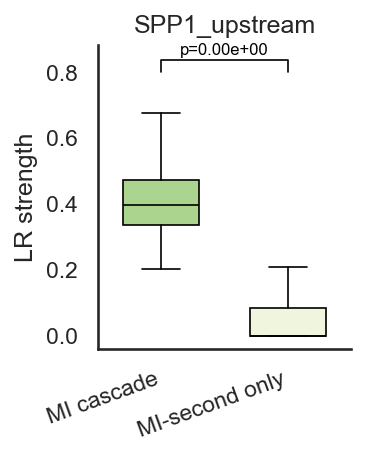

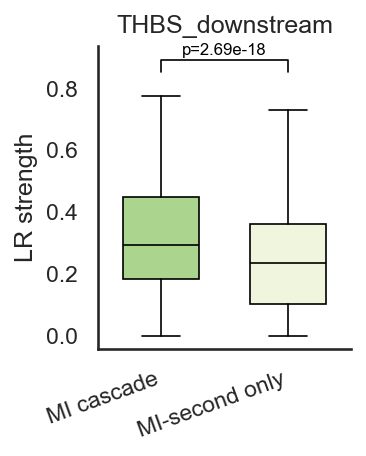

In [29]:
##LR
plot_two_group_feature_boxes(
    score_dict=results.pathway_metric_dict("lr_strength"),
    ylabel="LR strength",
    output_path=os.path.join(output_dir, f"LRstrength_{ct1_cur}-{ct2_cur}-{ct3_cur}"),
    show=True,
)

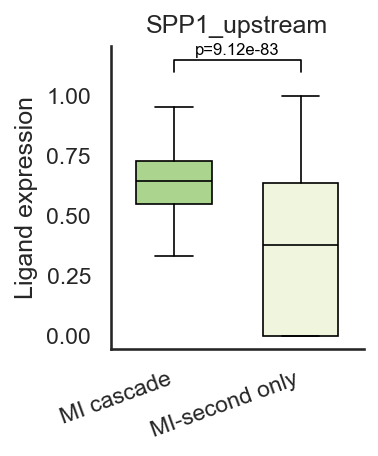

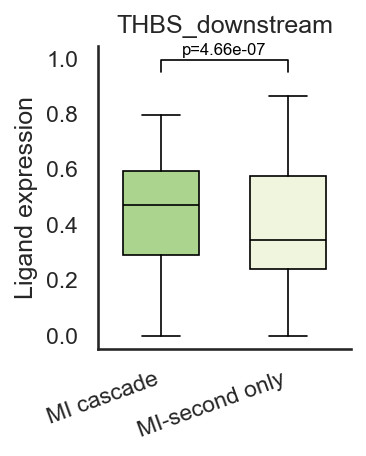

In [30]:
##Ligand expression
plot_two_group_feature_boxes(
    score_dict=results.pathway_metric_dict("ligand_expression"),
    ylabel="Ligand expression",
    output_path=os.path.join(output_dir, f"LigandExpression_{ct1_cur}-{ct2_cur}-{ct3_cur}"),
    show=True,
)

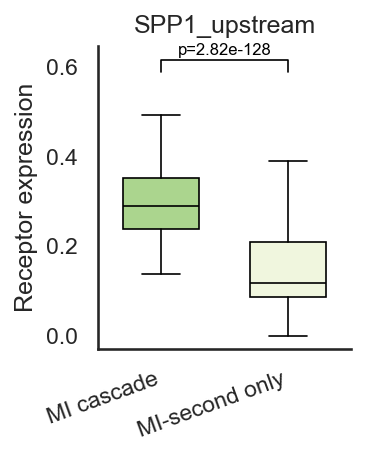

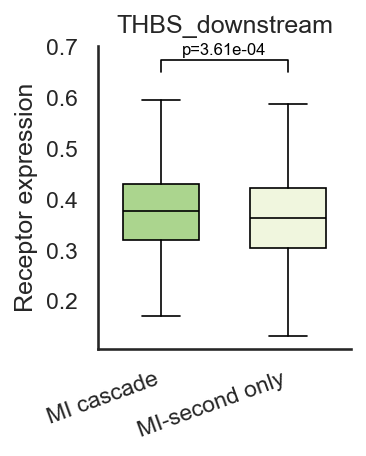

In [31]:
##Receptor expression
plot_two_group_feature_boxes(
    score_dict=results.pathway_metric_dict("receptor_expression"),
    ylabel="Receptor expression",
    output_path=os.path.join(output_dir, f"ReceptorExpression_{ct1_cur}-{ct2_cur}-{ct3_cur}"),
    show=True,
)

### Step7: Plot gene program scores between cascaded vs non-cascaded triplets

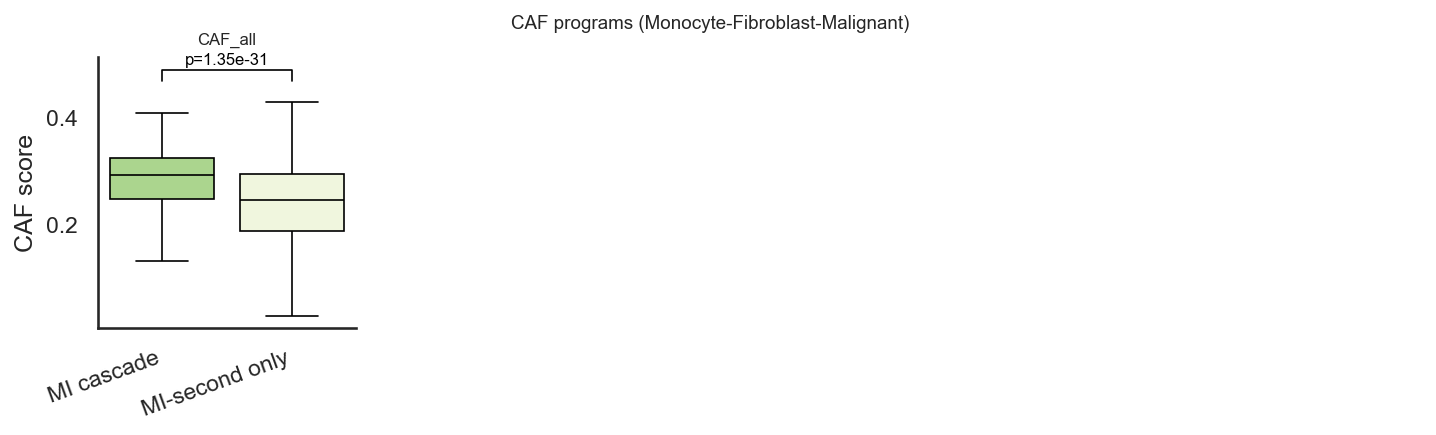

In [32]:
##CAF programs
plot_facet_boxplots(
    score_dict=results.gene_program_category_dict("CAF"),
    ylabel="CAF score",
    figure_title=f"CAF programs ({ct1_cur}-{ct2_cur}-{ct3_cur})",
    output_path=os.path.join(output_dir, f"CAF_{ct1_cur}-{ct2_cur}-{ct3_cur}.pdf"),
    show=True,
)

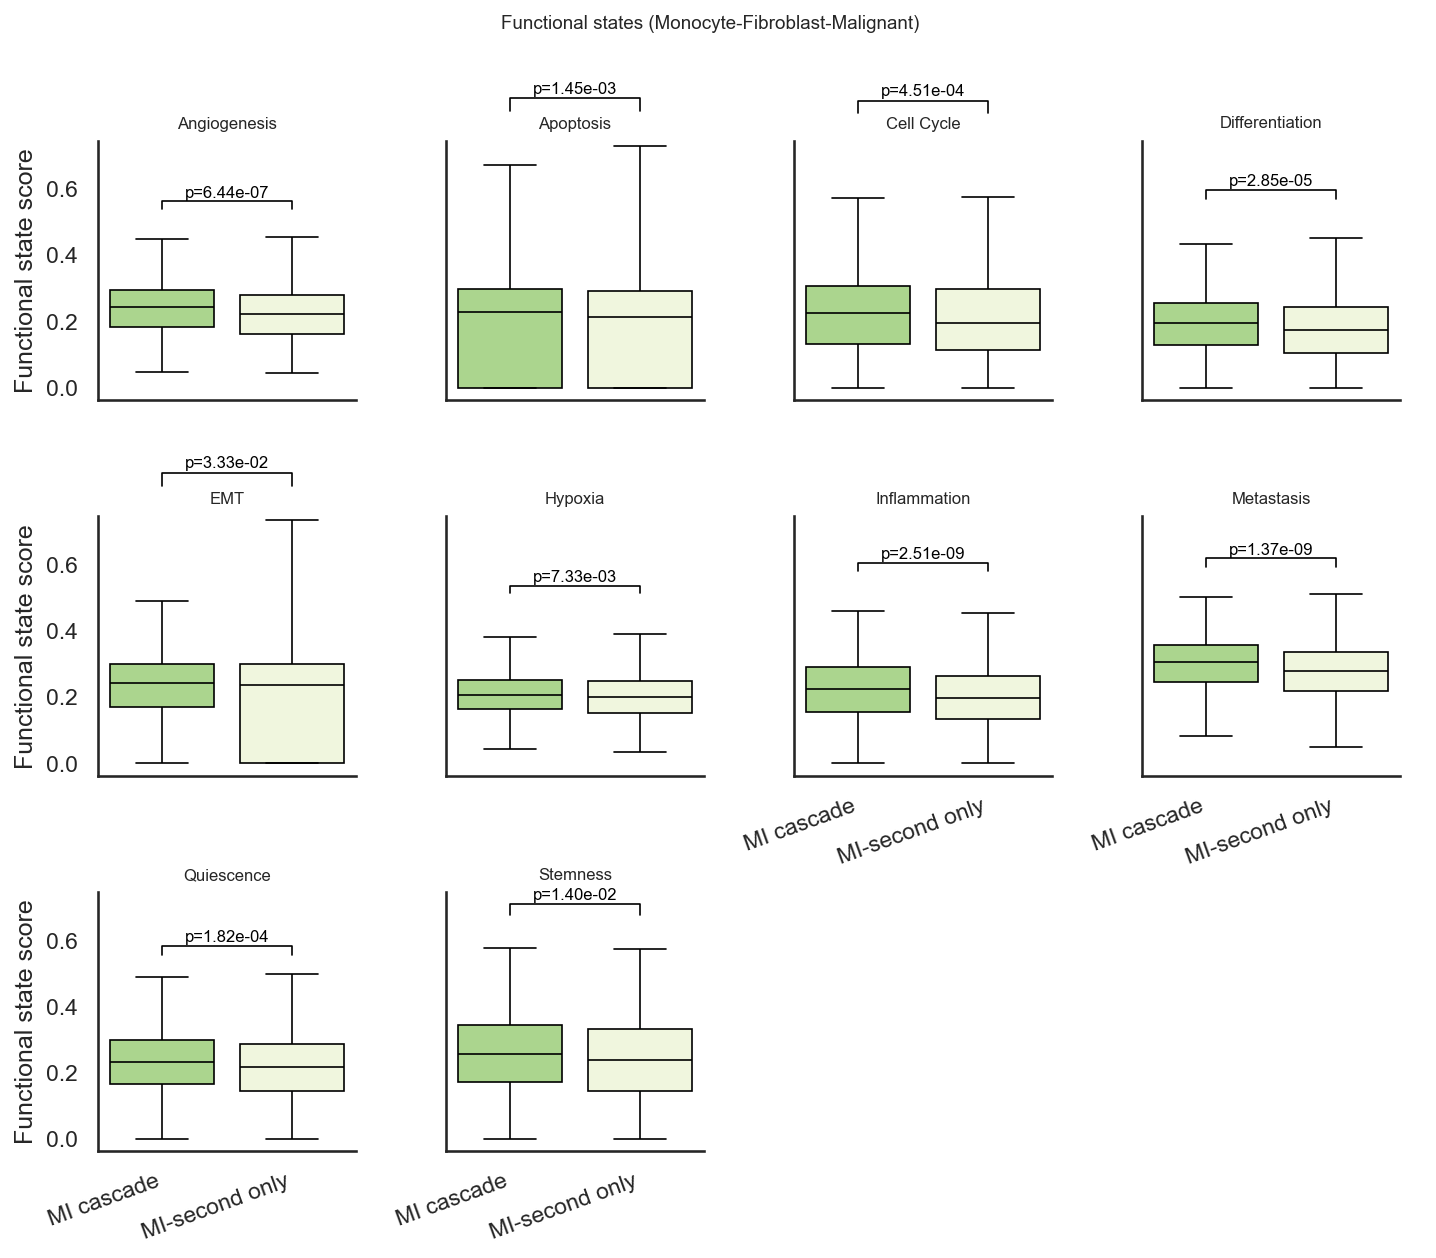

In [33]:
##Functional programs
plot_facet_boxplots(
    score_dict=results.gene_program_category_dict("Functional"),
    ylabel="Functional state score",
    figure_title=f"Functional states ({ct1_cur}-{ct2_cur}-{ct3_cur})",
    output_path=os.path.join(output_dir, f"Functional_{ct1_cur}-{ct2_cur}-{ct3_cur}.pdf"),
    show=True,
)

### Step8: DEG and GO enrichment for downstream malignant cells (the third cell) in selected triplet groups

This section compares the third cell in `BothPos` versus `OnlyMIsecond` triplets for the currently selected MI cascade and cell-type triple.
The code is written as a reusable pipeline so that it can be applied to a new dataset with minimal changes.

group
BothPos         1376
OnlyMIsecond    5364
Name: cell_index, dtype: int64


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[Saved DEG table] D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15\DEG_cell3_BothPos_vs_OnlyMIsecond_Monocyte-Fibroblast-Malignant.csv
#Upregulated genes in cell3_BothPos_up_Monocyte-Fibroblast-Malignant: 124
[Saved GO results] D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15\GO_enrichment_cell3_BothPos_up_Monocyte-Fibroblast-Malignant.csv


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:4537: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


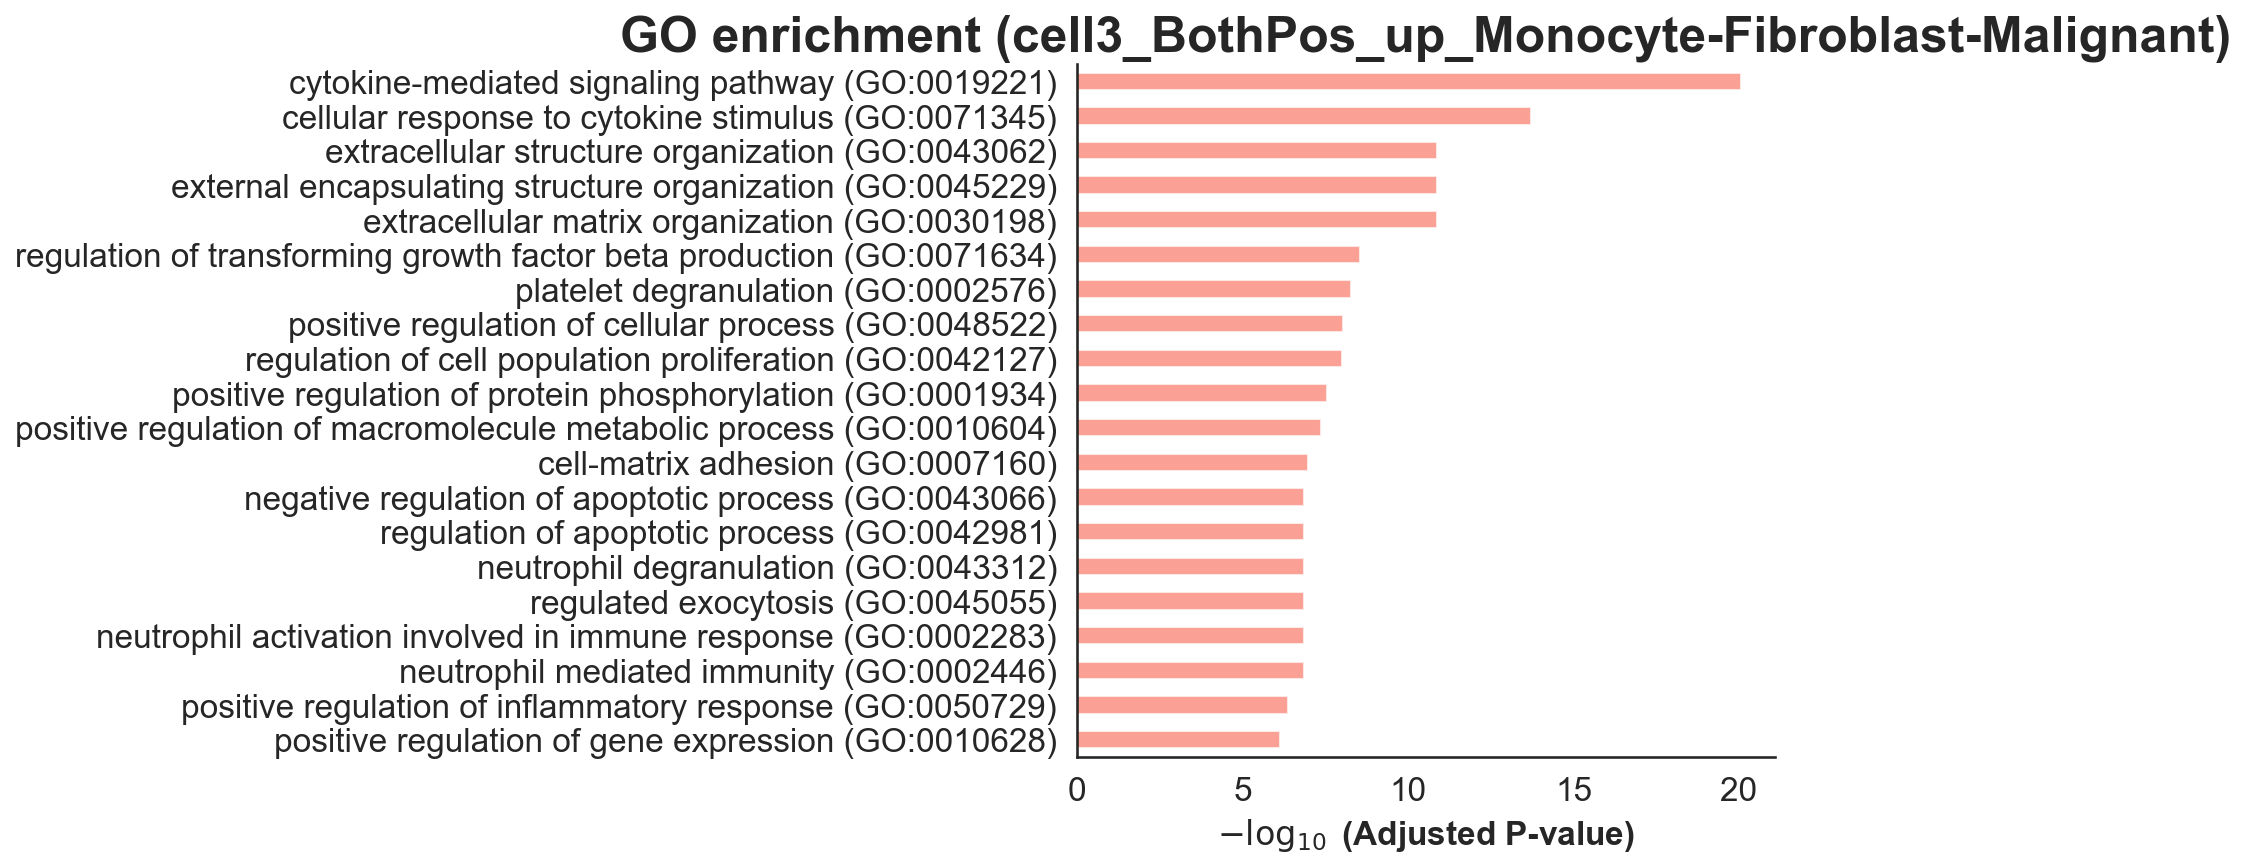

[Saved GO barplot] D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15\GO_barplot_cell3_BothPos_up_Monocyte-Fibroblast-Malignant.png
[Saved term table] D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15\TopTerms_term2genes_cell3_BothPos_up_Monocyte-Fibroblast-Malignant.csv
[Saved term2genes] D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15\term2genes_cell3_BothPos_up_Monocyte-Fibroblast-Malignant.pkl


In [34]:
from SpiderNet.analysis import run_triplet_cell_deg_go_pipeline
deg_go_out = run_triplet_cell_deg_go_pipeline(
    results=results,
    adata_list=adata_list,
    output_dir=output_dir,
    prefix=f"{ct1_cur}-{ct2_cur}-{ct3_cur}",
    groups=("BothPos", "OnlyMIsecond"),
    target_cell_position=2,   # cell3 in the triplet
    prefer_layer="counts",   # set to None to use adata.X
    normalize_log1p=True,
    organism="human",        # switch to "Mouse" for mouse data
    gene_sets=("GO_Biological_Process_2021",),
    lfc_thresh=0.5,
    padj_thresh=0.05,
    top_n_terms=20,
    show=True,
)

term2genes = deg_go_out["term2genes"]
deg_go_out["deg_term_df"].head()

##Save term2genes for later use (optional)
import pickle
with open(f"{output_dir}/term2genes_{ct1_cur}-{ct2_cur}-{ct3_cur}.pkl", "wb") as f:
    pickle.dump(term2genes, f)


In [35]:
# Example 3: GO terms scored on cell3
with open(f"{output_dir}/term2genes_{ct1_cur}-{ct2_cur}-{ct3_cur}.pkl", "rb") as f:
    term2genes = pickle.load(f)

go_specs = build_gene_program_specs_from_dict(
    program_dict=term2genes,
    cell_position=2,
    category="GO",
)

In [36]:
analyzer2 = MICascadeAnalyzer(
    adata_list=adata_list,
    factor_envir_norm_list=Factor_envir_list,
    hyper_edge_adj_list=result['hyper_edge_adj_list'],
    spidernet_data_list=SpiderNet_data_pyg_list,
    lr_meta=lr_meta,
    cascade_definition=cascade_def,
    pathway_specs=pathway_specs,
    gene_program_specs=go_specs,
    config=analysis_config,
)

results2 = analyzer2.run()



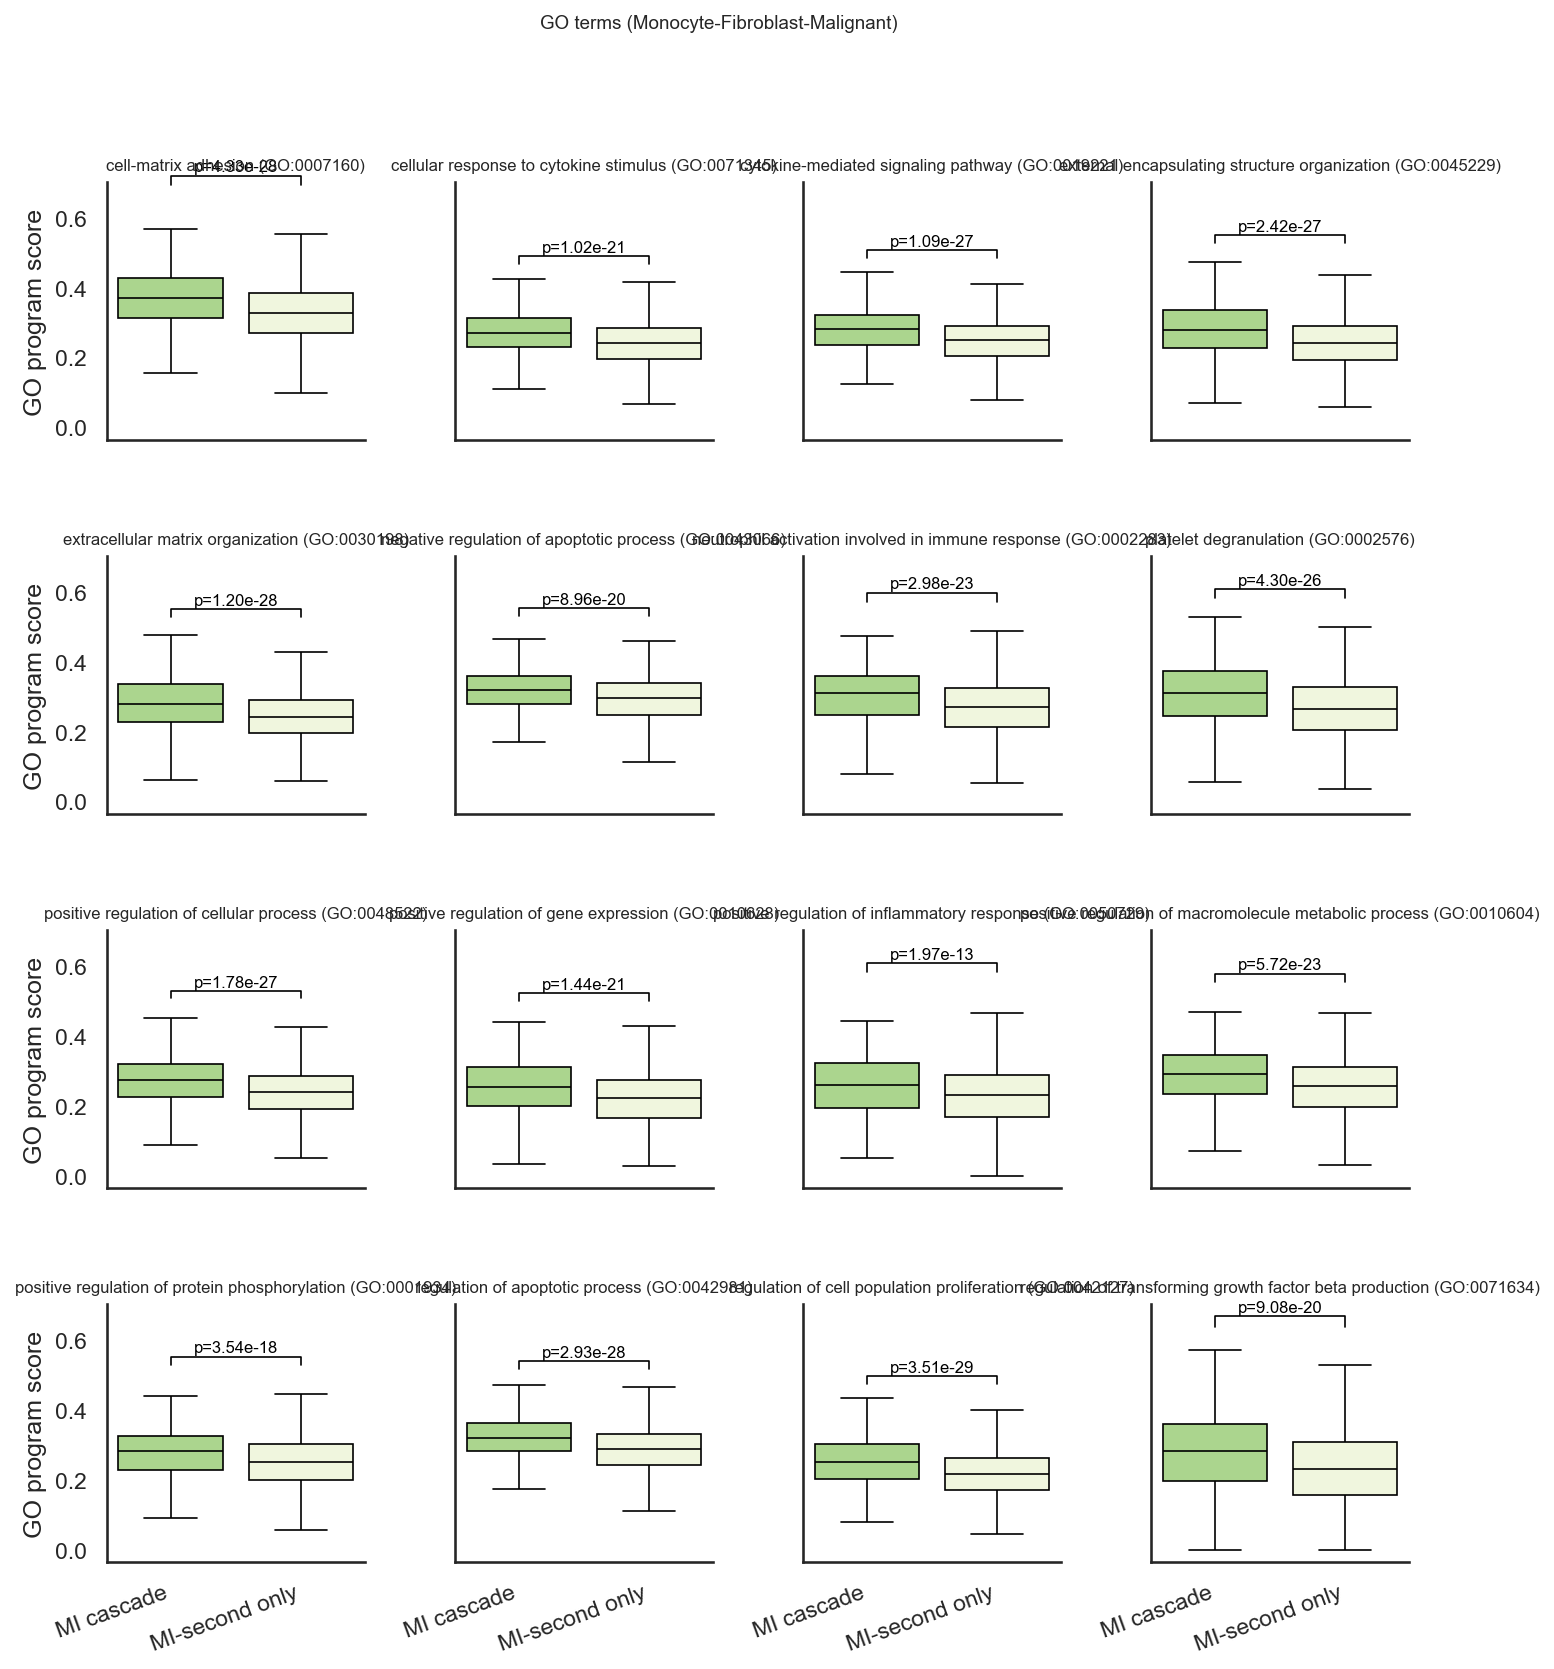

In [37]:
plot_facet_boxplots(
    score_dict=results2.gene_program_category_dict("GO"),
    ylabel="GO program score",
    figure_title=f"GO terms ({ct1_cur}-{ct2_cur}-{ct3_cur})",
    output_path=os.path.join(output_dir, f"GO_{ct1_cur}-{ct2_cur}-{ct3_cur}.pdf"),
    show=True,
)